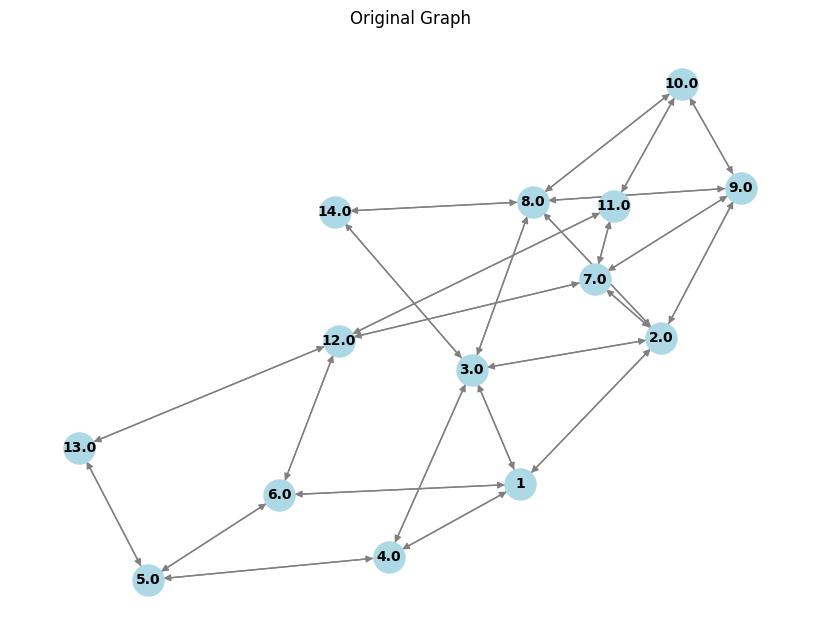

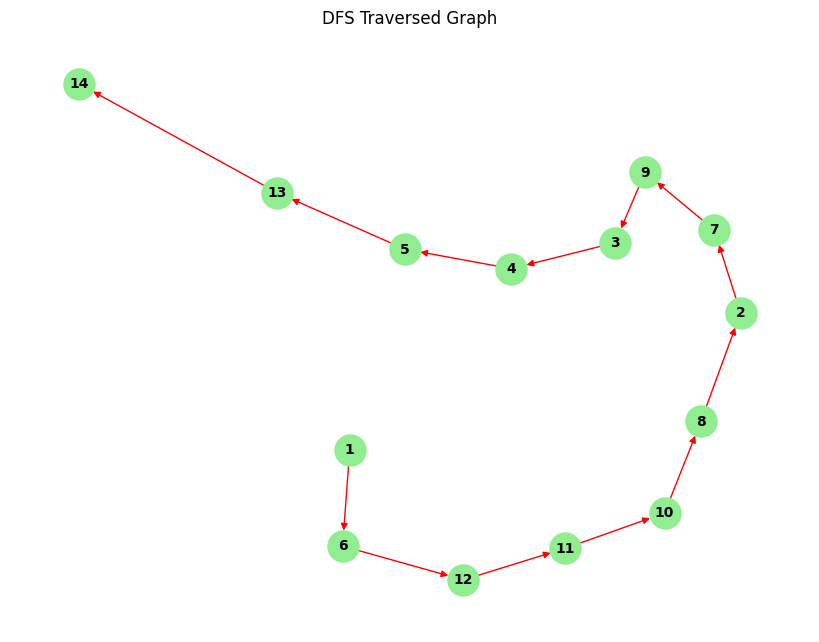

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

def print_og_graph():
    
    graphNodes = pd.read_csv(r"C:\Users\aarya\Desktop\3rd YEAR\sem 6\AI lab\graphNodes.csv")
    
    # create directed graph
    G = nx.DiGraph()
    
    # Add edges to the graph
    for _, row in graphNodes.iterrows():
        node = int(row['nodes'])
        neighbours = row[1:].dropna().tolist()
        for neighbour in neighbours:
            G.add_edge(node, neighbour)

    # Generate positions for nodes
    pos = nx.spring_layout(G)  # Use a spring layout for better visualization

    plt.figure(figsize=(8, 6))

    # Draw the graph
    nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=500, font_size=10, font_weight='bold', edge_color='gray')
    
    plt.title("Original Graph")
    plt.show()

def dfs_recursive(graph, start, visisted=None):
    
    if visisted is None:
        visisted = set()
        
    visisted.add(start)
    dfs_order = [start]
    
    for neighbour in graph.get(start, []):
        if neighbour not in visisted:
            dfs_order.extend(dfs_recursive(graph, neighbour, visisted))
    
    return dfs_order

def dfs_non_recursive(graph, start):
    
    visisted = set()
    stack = [start]
    dfs_order = []
    
    while stack:
        node = stack.pop()
        if node not in visisted:
            visisted.add(node)
            dfs_order.append(node)
            
            for neighbour in graph.get(node, []):
                if neighbour not in visisted:
                    stack.append(neighbour)
                    
    return dfs_order
    
def print_dfs_graph(graph, traversal_order):
    G = nx.DiGraph()

    # Add edges based on traversal order
    for i in range(len(traversal_order) - 1):
        G.add_edge(traversal_order[i], traversal_order[i + 1])

    # Generate positions for nodes
    pos = nx.spring_layout(G)  # Use a spring layout for better visualization

    plt.figure(figsize=(8, 6))

    # Draw the graph
    nx.draw(G, pos, with_labels=True, node_color='lightgreen', node_size=500, font_size=10, font_weight='bold', edge_color='red')

    plt.title("DFS Traversed Graph")
    plt.show()
    
def create_graph_from_csv(csv_path):
    graphNodes = pd.read_csv(csv_path)
    graph = {}
    for _, row in graphNodes.iterrows():
        node = int(row['nodes'])
        neighbours = row[1:].dropna().tolist()
        graph[node] = [int(neighbour) for neighbour in neighbours]
    return graph
    
print_og_graph()

# Example usage
csv_path = r"C:\Users\aarya\Desktop\3rd YEAR\sem 6\AI lab\graphNodes.csv"

# Step 1: Create graph dictionary from CSV
graph = create_graph_from_csv(csv_path)

startNode = int(input("Enter starting point: "))

# Step 2: Perform DFS traversal
rec_traversal_order = dfs_recursive(graph, startNode) 
non_rec_traversal_order = dfs_non_recursive(graph, startNode)

# Step 3: Visualize the DFS Traversal
Select_algo = int(input("Select algorithm; 1-Recursive DFS, 2-Non-Recursive DFS"))
if(Select_algo == 1):
    print_dfs_graph(graph, rec_traversal_order)
elif(Select_algo == 2):
    print_dfs_graph(graph, non_rec_traversal_order)

